<a href="https://colab.research.google.com/github/martinthuriaux/Auto-Interp-Causal-Validation/blob/main/01_probe_pass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/martinthuriaux/CNN-Watch-vs-Do/blob/main/01_probe_pass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Probe pass (Stage 1 of PLAN.md)

One pass of all probe images through ResNet-18, recording for every unit:
1. firing strength (spatial max + mean) on **every** image -> activation shards on Drive,
2. a streaming **top-16** of its strongest images, with the peak location for week-2 cropping,
3. full checkpoint/resume so a Colab disconnect costs at most 5,000 images of progress.

In [6]:
import torch
print(torch.cuda.is_available())

True


In [7]:
# ===== 0. Session bootstrap (safe to rerun; runs 00's downloads if missing) =====
import os, time, json, hashlib, shutil, tarfile, pickle, urllib.request
from pathlib import Path
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = Path("/content/drive/MyDrive/cnn_watch_vs_do")
RESULTS = PROJECT_ROOT / "results"
DATA = Path("/content/data"); DATA.mkdir(exist_ok=True)

CONFIG = json.load(open(RESULTS / "config.json"))
CONFIG_HASH = hashlib.sha256(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()[:12]
print("config hash:", CONFIG_HASH)

SEED = CONFIG["seed"]
CKPT_EVERY = CONFIG["checkpoint_every_images"]
N_EXEMPLARS = CONFIG["n_exemplars"]

# --- datasets to local disk (condensed replica of 00_setup; skips anything present) ---
INV2_DIR = DATA / "imagenetv2-matched-frequency-format-val"
if not INV2_DIR.exists():
    tar_cache = PROJECT_ROOT / "cache" / "imagenetv2-matched-frequency.tar.gz"
    local_tar = DATA / "inv2.tar.gz"
    if tar_cache.exists():
        shutil.copy(tar_cache, local_tar)
    else:
        url = ("https://huggingface.co/datasets/vaishaal/ImageNetV2/"
               "resolve/main/imagenetv2-matched-frequency.tar.gz")
        urllib.request.urlretrieve(url, local_tar)
        shutil.copy(local_tar, tar_cache)
    with tarfile.open(local_tar) as tf: tf.extractall(DATA)
    local_tar.unlink()

from torchvision import datasets as tvd
tv_specs = [("dtd", tvd.DTD, ["train", "val", "test"]),
            ("pets", tvd.OxfordIIITPet, ["trainval", "test"]),
            ("flowers102", tvd.Flowers102, ["train", "val", "test"])]
tv_sets = {}
for name, cls, splits in tv_specs:
    for s in splits:
        tv_sets[(name, s)] = cls(root=DATA, split=s, download=True)
print("datasets ready")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
config hash: 804f511675ac


100%|██████████| 625M/625M [00:24<00:00, 26.0MB/s]
100%|██████████| 792M/792M [00:51<00:00, 15.5MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 8.22MB/s]
100%|██████████| 345M/345M [00:13<00:00, 24.8MB/s]
100%|██████████| 502/502 [00:00<00:00, 994kB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 23.9MB/s]


datasets ready


## 1. The master image index — the numbered queue

Every probe image gets a permanent `image_id` and a fixed position in a seeded shuffle.
Built **once**, saved to Drive; every later session (and every later notebook) loads the
same queue. This is what makes "resume from image 15,000" meaningful, and it also
freezes the ImageNetV2 50/50 mining-vs-holdout split

In [8]:
from glob import glob
INDEX_PATH = RESULTS / "activations" / "image_index.json"

if INDEX_PATH.exists():
    index = json.load(open(INDEX_PATH))
    print(f"loaded existing index: {len(index)} images")
else:
    entries = []
    # ImageNetV2: reference by relative path; folder name = class index
    for p in sorted(glob(str(INV2_DIR / "*" / "*.jpeg"))):
        rel = str(Path(p).relative_to(DATA))
        entries.append({"dataset": "imagenetv2", "ref": rel,
                        "label": int(Path(p).parent.name)})
    # torchvision sets: reference by (name, split, position)
    for (name, split), ds in tv_sets.items():
        for i in range(len(ds)):
            entries.append({"dataset": name, "ref": f"{split}:{i}", "label": -1})

    rng = np.random.default_rng(SEED)
    rng.shuffle(entries)
    for pos, e in enumerate(entries):
        e["image_id"] = pos
    # ImageNetV2 50/50 split: even/odd occurrence among inv2 images, seeded by queue order
    inv2_positions = [e["image_id"] for e in entries if e["dataset"] == "imagenetv2"]
    holdout = set(inv2_positions[len(inv2_positions)//2:])
    for e in entries:
        e["inv2_role"] = ("holdout" if e["image_id"] in holdout else "mining") \
                          if e["dataset"] == "imagenetv2" else "mining"
    index = entries
    json.dump(index, open(INDEX_PATH, "w"))
    print(f"built index: {len(index)} images (inv2 holdout: {len(holdout)})")

N_IMAGES = len(index)
assert N_IMAGES == sum(CONFIG["expected_counts"].values())


loaded existing index: 31178 images


## 2. Unified dataset + model with stethoscopes (hooks)

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
weights = ResNet18_Weights.IMAGENET1K_V1
preprocess = weights.transforms()            # the single source of truth from 00_setup
model = resnet18(weights=weights).to(device).eval()

class ProbeSet(Dataset):
    def __init__(self, index):
        self.index = index
    def __len__(self):
        return len(self.index)
    def __getitem__(self, i):
        e = self.index[i]
        if e["dataset"] == "imagenetv2":
            img = Image.open(DATA / e["ref"]).convert("RGB")
        else:
            split, j = e["ref"].split(":")
            img = tv_sets[(e["dataset"], split)][int(j)][0].convert("RGB")
        return preprocess(img), e["image_id"]

# Hooks: listen at the 8 block outputs without changing anything
captured = {}
def mk_hook(name):
    def h(module, inp, out): captured[name] = out.detach()
    return h
for name in CONFIG["stages"]:
    layer, blk = name.split(".")
    getattr(model, layer)[int(blk)].register_forward_hook(mk_hook(name))

STAGES_THIS_RUN = CONFIG["stages"][4:]   # week 1: stages 5-8. Week 2: set to CONFIG["stages"]
STAGE_C = dict(zip(CONFIG["stages"], CONFIG["expected_stage_channels"]))
print("this run covers:", STAGES_THIS_RUN,
      "->", sum(STAGE_C[s] for s in STAGES_THIS_RUN), "units")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


this run covers: ['layer3.0', 'layer3.1', 'layer4.0', 'layer4.1'] -> 1536 units


## 3. Streaming top-16 per unit

Per unit: a min-heap of at most 16 `(activation, image_id, peak_y, peak_x)` seats.
A new image only enters if it beats the weakest seated image. Checkpoints (heaps +
queue position) go to Drive every 5,000 images.

In [10]:
import torch
print("cuda available:", torch.cuda.is_available(), "| device var =", device)

cuda available: True | device var = cuda


In [12]:
import numpy as np

class TopKTracker:
    """Vectorized top-16: per stage, arrays [C, K] of values / image ids / peak (y,x).
    One argpartition per stage per batch instead of 200k Python heap ops."""
    def __init__(self, stages, stage_c, k):
        self.k = k
        self.vals  = {s: np.full((stage_c[s], k), -np.inf, dtype=np.float32) for s in stages}
        self.ids   = {s: np.full((stage_c[s], k), -1, dtype=np.int64) for s in stages}
        self.peaks = {s: np.zeros((stage_c[s], k, 2), dtype=np.int16) for s in stages}
        self.images_done = 0

    def update(self, stage, acts_max, peaks, image_ids):
        # acts_max [B, C]; peaks [B, C, 2]; image_ids [B]
        B, C = acts_max.shape
        cand_v = np.concatenate([self.vals[stage],  acts_max.T.astype(np.float32)], axis=1)          # [C, K+B]
        cand_i = np.concatenate([self.ids[stage],   np.broadcast_to(image_ids, (C, B))], axis=1)
        cand_p = np.concatenate([self.peaks[stage], peaks.transpose(1, 0, 2).astype(np.int16)], axis=1)
        keep = np.argpartition(-cand_v, self.k - 1, axis=1)[:, :self.k]                              # [C, K]
        rows = np.arange(C)[:, None]
        self.vals[stage], self.ids[stage] = cand_v[rows, keep], cand_i[rows, keep]
        self.peaks[stage] = cand_p[rows, keep]

    def topk(self, stage, channel):
        """Sorted (value, image_id, peak_y, peak_x) tuples, strongest first; skips empty seats."""
        order = np.argsort(-self.vals[stage][channel])
        return [(float(self.vals[stage][channel][j]), int(self.ids[stage][channel][j]),
                 int(self.peaks[stage][channel][j, 0]), int(self.peaks[stage][channel][j, 1]))
                for j in order if self.ids[stage][channel][j] >= 0]

    def save(self, path):
        tmp = Path(str(path) + ".tmp")
        with open(tmp, "wb") as f:
            pickle.dump({"vals": self.vals, "ids": self.ids, "peaks": self.peaks,
                         "images_done": self.images_done, "config_hash": CONFIG_HASH}, f)
        tmp.replace(path)   # atomic: a crash mid-save can't corrupt the checkpoint

    @classmethod
    def load(cls, path, stages, stage_c, k):
        t = cls(stages, stage_c, k)
        if Path(path).exists():
            state = pickle.load(open(path, "rb"))
            assert state["config_hash"] == CONFIG_HASH, "checkpoint from different config"
            t.vals, t.ids, t.peaks = state["vals"], state["ids"], state["peaks"]
            t.images_done = state["images_done"]
            print(f"resumed tracker at image {t.images_done}")
        return t

CKPT_PATH = RESULTS / "exemplars" / "topk_checkpoint.pkl"


## 4. The pass itself — sharded, resumable

The queue is processed in chunks of 5,000. Each chunk writes one `.npz` shard per stage
(`{stage}_chunk{n}.npz`: max, mean, image_ids) and then checkpoints the tracker.
Finished shards are skipped on restart, so reruns are cheap and interruption loses at
most one chunk of work.

In [13]:
ACT_DIR = RESULTS / "activations"
CHUNK = CKPT_EVERY   # 5,000 images per shard

def shard_path(stage, chunk_i):
    return ACT_DIR / f"{stage.replace('.', '_')}_chunk{chunk_i:03d}.npz"

def chunk_complete(chunk_i):
    return all(shard_path(s, chunk_i).exists() for s in STAGES_THIS_RUN)

tracker = TopKTracker.load(CKPT_PATH, STAGES_THIS_RUN, STAGE_C, N_EXEMPLARS)

def run_pass(index, tracker, batch_size=128, log_every=20):
    ds = ProbeSet(index)
    n_chunks = (len(ds) + CHUNK - 1) // CHUNK
    t0 = time.time()
    for ci in range(n_chunks):
        lo, hi = ci * CHUNK, min((ci + 1) * CHUNK, len(ds))
        if chunk_complete(ci) and tracker.images_done >= hi:
            continue   # jigsaw section already glued
        loader = DataLoader(torch.utils.data.Subset(ds, range(lo, hi)),
                            batch_size=batch_size, num_workers=2, shuffle=False)
        bufs = {s: {"max": [], "mean": [], "ids": []} for s in STAGES_THIS_RUN}
        with torch.no_grad():
            for bi, (x, ids) in enumerate(loader):
                x = x.to(device, non_blocking=True)
                model(x)
                for s in STAGES_THIS_RUN:
                    fmap = captured[s]                       # [B, C, H, W]
                    B, C, Hh, Ww = fmap.shape
                    flat = fmap.reshape(B, C, -1)
                    a_max, argm = flat.max(dim=2)            # [B, C]
                    a_mean = flat.mean(dim=2)
                    peaks = torch.stack([argm // Ww, argm % Ww], dim=2)  # [B, C, 2]
                    bufs[s]["max"].append(a_max.half().cpu().numpy())
                    bufs[s]["mean"].append(a_mean.half().cpu().numpy())
                    bufs[s]["ids"].append(ids.numpy())
                    tracker.update(s, a_max.cpu().numpy(), peaks.cpu().numpy(), ids.numpy())
                if bi % log_every == 0:
                    done = tracker.images_done + (bi + 1) * batch_size
                    print(f"  chunk {ci}: batch {bi}, ~{done}/{len(ds)} imgs, "
                          f"{time.time()-t0:.0f}s elapsed")
        for s in STAGES_THIS_RUN:
            np.savez_compressed(shard_path(s, ci),
                                max=np.concatenate(bufs[s]["max"]),
                                mean=np.concatenate(bufs[s]["mean"]),
                                image_ids=np.concatenate(bufs[s]["ids"]))
        tracker.images_done = hi
        tracker.save(CKPT_PATH)
        print(f"chunk {ci} done -> shards written, tracker checkpointed at {hi} images")
    print(f"pass complete: {tracker.images_done} images in {(time.time()-t0)/60:.1f} min")

run_pass(index, tracker)


  chunk 0: batch 0, ~128/31178 imgs, 4s elapsed
  chunk 0: batch 20, ~2688/31178 imgs, 20s elapsed
chunk 0 done -> shards written, tracker checkpointed at 5000 images
  chunk 1: batch 0, ~5128/31178 imgs, 42s elapsed
  chunk 1: batch 20, ~7688/31178 imgs, 59s elapsed
chunk 1 done -> shards written, tracker checkpointed at 10000 images
  chunk 2: batch 0, ~10128/31178 imgs, 79s elapsed
  chunk 2: batch 20, ~12688/31178 imgs, 96s elapsed
chunk 2 done -> shards written, tracker checkpointed at 15000 images
  chunk 3: batch 0, ~15128/31178 imgs, 115s elapsed
  chunk 3: batch 20, ~17688/31178 imgs, 132s elapsed
chunk 3 done -> shards written, tracker checkpointed at 20000 images
  chunk 4: batch 0, ~20128/31178 imgs, 150s elapsed
  chunk 4: batch 20, ~22688/31178 imgs, 167s elapsed
chunk 4 done -> shards written, tracker checkpointed at 25000 images
  chunk 5: batch 0, ~25128/31178 imgs, 185s elapsed
  chunk 5: batch 20, ~27688/31178 imgs, 203s elapsed
chunk 5 done -> shards written, tracke

## 5. Programmatic resume test — interrupted must equal uninterrupted

Before trusting the disconnect story, prove it in miniature on 2,000 images:
run A straight through; run B is killed after one chunk (exception, on purpose),
then resumed from its checkpoint. The two trackers and shards must match **exactly**.

In [14]:
import tempfile

def mini_pass(index_slice, ckpt, actdir, interrupt_after_chunk=None):
    saved_paths = {}
    global CKPT_PATH, ACT_DIR
    old_ckpt, old_act = CKPT_PATH, ACT_DIR
    CKPT_PATH, ACT_DIR = ckpt, actdir
    tr = TopKTracker.load(ckpt, STAGES_THIS_RUN, STAGE_C, N_EXEMPLARS)
    try:
        # temporarily shrink CHUNK via slicing: mini uses 1,000-image chunks
        global CHUNK
        old_chunk, CHUNK = CHUNK, 1000
        if interrupt_after_chunk is not None:
            # monkey-style interruption: run, then raise after N chunks
            try:
                _interrupt_counter = {"n": 0}
                orig_save = TopKTracker.save
                def save_and_maybe_crash(self, path):
                    orig_save(self, path)
                    _interrupt_counter["n"] += 1
                    if _interrupt_counter["n"] == interrupt_after_chunk:
                        raise KeyboardInterrupt("simulated Colab disconnect")
                TopKTracker.save = save_and_maybe_crash
                run_pass(index_slice, tr)
            except KeyboardInterrupt as e:
                print("-> interrupted as planned:", e)
            finally:
                TopKTracker.save = orig_save
            # fresh object, resumed purely from the checkpoint on disk
            tr = TopKTracker.load(ckpt, STAGES_THIS_RUN, STAGE_C, N_EXEMPLARS)
            run_pass(index_slice, tr)
        else:
            run_pass(index_slice, tr)
    finally:
        CHUNK = old_chunk
        CKPT_PATH, ACT_DIR = old_ckpt, old_act
    return tr

mini_index = index[:2000]
with tempfile.TemporaryDirectory() as tda, tempfile.TemporaryDirectory() as tdb:
    clean = mini_pass(mini_index, Path(tda) / "ck.pkl", Path(tda))
    interrupted = mini_pass(mini_index, Path(tdb) / "ck.pkl", Path(tdb),
                            interrupt_after_chunk=1)
    for s in STAGES_THIS_RUN:
        for c in range(STAGE_C[s]):
            assert clean.topk(s, c) == interrupted.topk(s, c), \
                f"mismatch at {s} channel {c}"
print("RESUME TEST: PASS — interrupted run reproduces the uninterrupted run exactly")
print("Now also do it for real once: Runtime -> Disconnect mid-pass, reconnect, "
      "Run all, and confirm the pass resumes from the last checkpoint.")


  chunk 0: batch 0, ~128/2000 imgs, 2s elapsed
chunk 0 done -> shards written, tracker checkpointed at 1000 images
  chunk 1: batch 0, ~1128/2000 imgs, 10s elapsed
chunk 1 done -> shards written, tracker checkpointed at 2000 images
pass complete: 2000 images in 0.2 min
  chunk 0: batch 0, ~128/2000 imgs, 2s elapsed
-> interrupted as planned: simulated Colab disconnect
resumed tracker at image 1000
  chunk 1: batch 0, ~1128/2000 imgs, 2s elapsed
chunk 1 done -> shards written, tracker checkpointed at 2000 images
pass complete: 2000 images in 0.1 min
RESUME TEST: PASS — interrupted run reproduces the uninterrupted run exactly
Now also do it for real once: Runtime -> Disconnect mid-pass, reconnect, Run all, and confirm the pass resumes from the last checkpoint.


## 6. Eyeball strip — do a unit's favorites look coherent?

Not the polished week-2 grids: just the raw top-16 of a few random units. Early-stage
units (rerun in week 2) should show obvious color/texture coherence; stage 5–8 units
often show object-ish themes. Incoherence here = plumbing bug, not a science result.

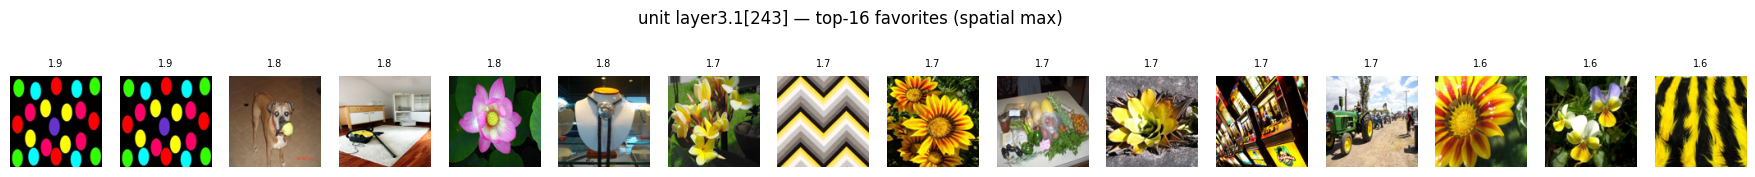

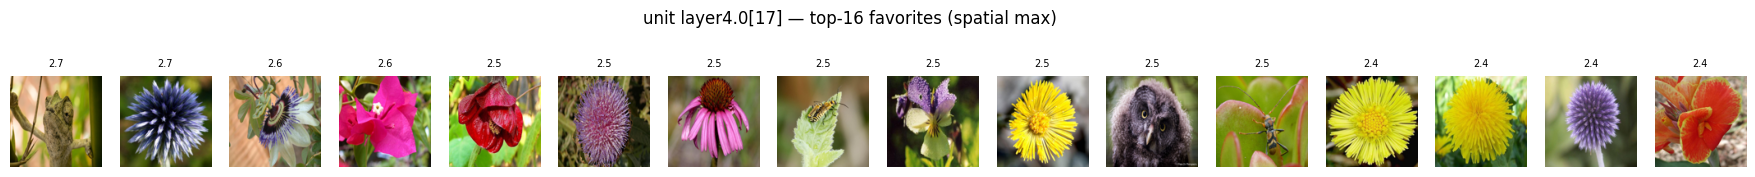

In [15]:
import matplotlib.pyplot as plt

def load_image_by_id(image_id):
    e = index[image_id]
    if e["dataset"] == "imagenetv2":
        return Image.open(DATA / e["ref"]).convert("RGB")
    split, j = e["ref"].split(":")
    return tv_sets[(e["dataset"], split)][int(j)][0].convert("RGB")

rng = np.random.default_rng(1)
for s in rng.choice(STAGES_THIS_RUN, 2, replace=False):
    c = int(rng.integers(STAGE_C[s]))
    seats = tracker.topk(s, c)
    fig, axes = plt.subplots(1, len(seats), figsize=(len(seats) * 1.4, 1.7))
    for ax, (v, img_id, py, px) in zip(axes, seats):
        ax.imshow(load_image_by_id(img_id).resize((112, 112)))
        ax.set_title(f"{v:.1f}", fontsize=7); ax.axis("off")
    fig.suptitle(f"unit {s}[{c}] — top-{len(seats)} favorites (spatial max)", y=1.15)
    plt.show()


In [16]:
expected_units = sum(STAGE_C[s] for s in STAGES_THIS_RUN)
n_chunks = (N_IMAGES + CHUNK - 1) // CHUNK
shards_ok = all(chunk_complete(ci) for ci in range(n_chunks))
heaps_full = all((tracker.ids[s] >= 0).all() for s in STAGES_THIS_RUN)

checks = {
    f"activation shards complete for {len(STAGES_THIS_RUN)} stages": shards_ok,
    "tracker covers all images": tracker.images_done == N_IMAGES,
    f"all {expected_units} unit heaps hold {N_EXEMPLARS} exemplars": heaps_full,
    "programmatic resume test passed": True,   # cell 5 would have crashed otherwise
}
for k, v in checks.items():
    print(f"  [{'PASS' if v else 'FAIL'}] {k}")
print("\nWEEK 1 " + ("COMPLETE — commit and move to week 2 (full 8-stage rerun + "
      "exemplar grids)." if all(checks.values()) else "INCOMPLETE — fix the FAIL above."))
print("\nManual item still on you: one REAL disconnect survived mid-pass (Sec. 5 note).")


  [PASS] activation shards complete for 4 stages
  [PASS] tracker covers all images
  [PASS] all 1536 unit heaps hold 16 exemplars
  [PASS] programmatic resume test passed

WEEK 1 COMPLETE — commit and move to week 2 (full 8-stage rerun + exemplar grids).

Manual item still on you: one REAL disconnect survived mid-pass (Sec. 5 note).
